# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [12]:
import seaborn as sns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [11]:
print(f'1) В датасете всего {data['text'].nunique(dropna=True)} текстов\n')
print(f'2) Количество текстов в категориях:\n{data['category'].value_counts()}')

1) В датасете всего 1986 текстов

2) Количество текстов в категориях:
category
0    999
1    987
Name: count, dtype: int64


### **2. Анализ данных**

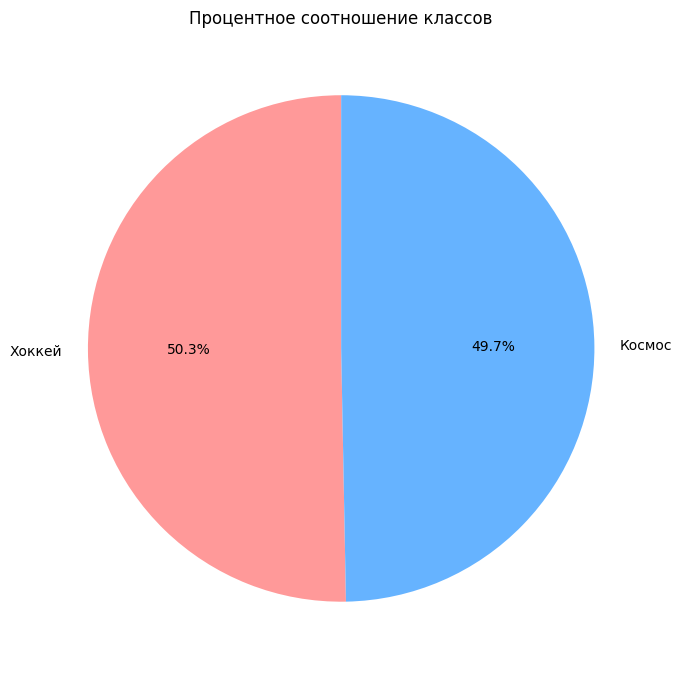

In [25]:
# 0 = хоккей, 1 = космос
counts = data['category'].value_counts()
labels = ['Хоккей', 'Космос']

plt.figure(figsize=(7, 7))

class_counts = data['category'].value_counts().sort_index()
plt.pie(class_counts, labels=labels, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Процентное соотношение категорий')

plt.tight_layout()
plt.show()

**Вопрос:** Какая категория больше: хоккей или космос?

**Ответ:** Больше хоккей

### **3. Очистка текста**

In [27]:
data['text']

,text
0,From: mccall@mksol.dseg.ti.com (fred j mccall ...
1,From: epritcha@s.psych.uiuc.edu ( Evan Pritcha...
2,From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)\...
3,From: mse@cc.bellcore.com (25836-michael evenc...
4,From: apanjabi@guvax.acc.georgetown.edu\nSubje...
...,...
1981,From: mccall@mksol.dseg.ti.com (fred j mccall ...
1982,From: jecurt01@starbase.spd.louisville.edu (Jo...
1983,From: Anna Matyas <am2x+@andrew.cmu.edu>\nSubj...
1984,Subject: Re: SHARKS REVIEW Part 5: Left Wings\...


In [28]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccallmksoldsegticom fred j mccall subject re vandalizing the sky articleid mksolapr organizati


### **4. Создание признаков (векторизация)**

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_text'])

print(f'Получилось {X.shape[1]} слов')

Получилось 28383 слов


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

**Ответ:** 28383

### **5. Разделение данных**

In [37]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = vectorizer.transform(data['clean_text']) # (признаки)
y = data['category'] # (целевая переменная)

# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### **6. Обучение модели**

In [38]:
from sklearn.linear_model import LogisticRegression

# 1. Создайте модель логистической регрессии
model = LogisticRegression()

# 2. Обучите её на обучающих данных
model.fit(X_train, y_train)

# 3. Сделайте предсказания для тестовых данных
y_pred = model.predict(X_test)

### **7. Оценка модели**

In [40]:
from sklearn.metrics import accuracy_score

# Ваш код здесь
# 1. Вычислите accuracy (точность) модели
# 2. Выведите результат в процентах

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 99.25%


**Вопрос:** Какая точность у вашей модели? Что это значит?

**Ответ:** точность 99,25%. Это значит, что модель хорошо различает тексты про хоккей и космос

### **8. Анализ ошибок**

[[201   1]
 [  2 194]]


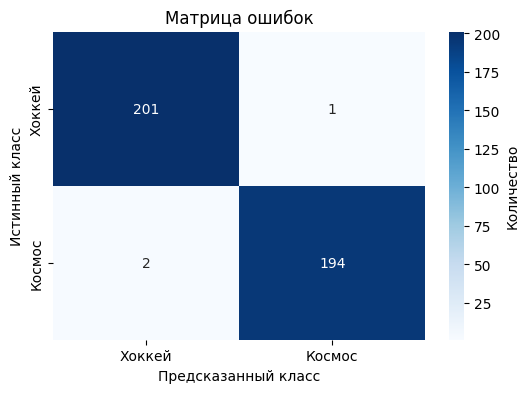

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

# визуализация
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Хоккей', 'Космос'],
            yticklabels=['Хоккей', 'Космос'],
            cbar_kws={'label': 'Количество'})
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

**Ответ:** 2